# 1. Setup & Imports
Mount Google Drive, install/import all packages used throughout the notebook (data handling, plotting, SQL, and ML libraries for RF/XGBoost/LightGBM/LSTM).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from scipy.io import loadmat
import numpy as np
np.set_printoptions(legacy="1.25")
import seaborn
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from datetime import datetime, timedelta
import sqlite3
from scipy.integrate import cumulative_trapezoid
!pip install "prettytable<3.10"

#from google.colab import drive
#drive.mount('/content/drive')

import os
import re
import kagglehub
from kagglehub import KaggleDatasetAdapter


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import xgboost as xgb
from xgboost import XGBRegressor

import lightgbm as lgb
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# List contents of the root of your Google Drive
#print(os.listdir('/content/drive/My Drive'))


# 2. Load & Parse Raw NASA Battery Data
A user named Patrick Fleith had kindly converted the original MATLAB files into CSV. This section not only converts MATLAB datenum vectors to Python `datetime`, it also then loop through every file/cycle to build three raw DataFrames: `charge_df`, `discharge_df`, `eis_df`.

In [2]:
DATA_DIR = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")
print(os.listdir(DATA_DIR))

['cleaned_dataset']


In [3]:
root = os.path.join(DATA_DIR, "cleaned_dataset")
print(os.listdir(root))

metadata = pd.read_csv(os.path.join(root, "metadata.csv"))
print(metadata.shape)
print(metadata.columns.tolist())
print(metadata.head())

# peek at one cycle file to see its columns
data_dir = os.path.join(root, "data")
sample_file = os.listdir(data_dir)[0]
sample = pd.read_csv(os.path.join(data_dir, sample_file))
print(sample_file)
print(sample.columns.tolist())
print(sample.head())

['data', 'extra_infos', 'metadata.csv']
(7565, 10)
['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']
        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   
1  impedance  [2010.       7.      21.      16.      53.    ...   
2     charge  [2010.       7.      21.      17.      25.    ...   
3  impedance                    [2010    7   21   20   31    5]   
4  discharge  [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   
1                   24      B0047        1    2  00002.csv   
2                    4      B0047        2    3  00003.csv   
3                   24      B0047        3    4  00004.csv   
4                    4      B0047        4    5  00005.csv   

             Capacity                   Re                

In [4]:
#creating dataframes for each state (charging, discharging, and EIS measurement)
metadata["Capacity"] = pd.to_numeric(metadata["Capacity"], errors="coerce")
metadata["Re"] = pd.to_numeric(metadata["Re"], errors="coerce")
metadata["Rct"] = pd.to_numeric(metadata["Rct"], errors="coerce")


def parse_start_time(s):
    """Parse the dataset's MATLAB-style date-vector string into a datetime."""
    if not isinstance(s, str) or not s.strip():
        return None
    inner = s.strip().strip("[]")
    inner = re.sub(r"[,\s]+", ",", inner.strip())
    parts = [float(x) for x in inner.split(",") if x]
    if len(parts) < 6:
        return None
    yr, mo, dy, hr, mi, sc = parts[:6]
    return datetime(int(yr), int(mo), int(dy), int(hr), int(mi), int(sc))


charge_frames, discharge_frames, eis_frames = [], [], []

for row in metadata.itertuples():
    cycle_path = os.path.join(data_dir, row.filename)
    df = pd.read_csv(cycle_path)
    n = len(df)

    cycle_start = parse_start_time(row.start_time)
    df["Cell_ID"] = row.battery_id
    df["Cycle_Number"] = row.test_id
    df["Ambient_Temperature"] = row.ambient_temperature
    df["Time_abs"] = cycle_start

    if row.type == "charge":
        charge_frames.append(df)
    elif row.type == "discharge":
        df["Capacity"] = row.Capacity
        discharge_frames.append(df)
    elif row.type == "impedance":
        for col in ["Sense_current", "Battery_current", "Current_ratio",
                    "Battery_impedance", "Rectified_Impedance"]:
            df[col] = df[col].apply(complex)
        df["Re"] = row.Re
        df["Rct"] = row.Rct
        eis_frames.append(df)

charge_df = pd.concat(charge_frames, ignore_index=True)
discharge_df = pd.concat(discharge_frames, ignore_index=True)
eis_df = pd.concat(eis_frames, ignore_index=True)

print(charge_df.shape, discharge_df.shape, eis_df.shape)

(6512876, 10) (770070, 11) (93888, 11)


In [5]:
#further peeking into the metadata to see the headers and values used in the data
extra_dir = os.path.join(root, "extra_infos")
print(os.listdir(extra_dir))

imp_row = metadata[metadata['type'] == 'impedance'].iloc[0]
imp_sample = pd.read_csv(os.path.join(root, "data", imp_row['filename']))
print(imp_row['filename'])
print(imp_sample.columns.tolist())
print(imp_sample.head())

['README_05_06_07_18.txt', 'README_25_26_27_28.txt', 'README_29_30_31_32.txt', 'README_33_34_36.txt', 'README_38_39_40.txt', 'README_41_42_43_44.txt', 'README_45_46_47_48.txt', 'README_49_50_51_52.txt', 'README_53_54_55_56.txt']
00002.csv
['Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance']
                             Sense_current  \
0  (928.3472290039062-48.499576568603516j)   
1   (922.0059814453125-52.15481185913086j)   
2   (920.0405883789062-52.19926452636719j)   
3  (914.2005615234375-52.371726989746094j)   
4  (911.2781372070312-45.477928161621094j)   

                           Battery_current  \
0      (228.7861328125-70.94481658935547j)   
1  (233.29783630371094-67.84492492675781j)   
2  (236.62075805664062-67.22105407714844j)   
3   (242.2973175048828-66.45936584472656j)   
4   (246.62347412109375-65.4150161743164j)   

                              Current_ratio  \
0    (3.76172584438583+0.9544956717274271j)   
1    (3.7038357

In [6]:
#prints all the readme (experimental notes for each battery dataset)
for f in sorted(os.listdir(extra_dir)):
    print(f"===== {f} =====")
    print(open(os.path.join(extra_dir, f), errors='ignore').read())
    print()

===== README_05_06_07_18.txt =====
Data Description:
A set of four Li-ion batteries (# 5, 6, 7 and 18) were run through 3 different operational profiles (charge, discharge and impedance) at room temperature. Charging was carried out in a constant current (CC) mode at 1.5A until the battery voltage reached 4.2V and then continued in a constant voltage (CV) mode until the charge current dropped to 20mA. Discharge was carried out at a constant current (CC) level of 2A until the battery voltage fell to 2.7V, 2.5V, 2.2V and 2.5V for batteries 5 6 7 and 18 respectively. Impedance measurement was carried out through an electrochemical impedance spectroscopy (EIS) frequency sweep from 0.1Hz to 5kHz. Repeated charge and discharge cycles result in accelerated aging of the batteries while impedance measurements provide insight into the internal battery parameters that change as aging progresses. The experiments were stopped when the batteries reached end-of-life (EOL) criteria, which was a 30% fa

Due to control software crashing (as noted in the readme file), batteries 49-52 will not be included in the dataset.

In [7]:
# Drop cells that failed early due to control-software crashes (B0049-B0052)
dropped_cells = ['B0049', 'B0050', 'B0051', 'B0052']
eis_df = eis_df[~eis_df['Cell_ID'].isin(dropped_cells)]
charge_df = charge_df[~charge_df['Cell_ID'].isin(dropped_cells)]
discharge_df = discharge_df[~discharge_df['Cell_ID'].isin(dropped_cells)]

In [8]:
#putting battery experimental conditions into a nested dictionary before creating a dataframe
battery_protocol = {
    # Batteries 5,6,7,18 — CC discharge 2A, room temp
    'B0005': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 24, 'cutoff_V': 2.7, 'endoflife_criteria': 0.30},
    'B0006': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 24, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},
    'B0007': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 24, 'cutoff_V': 2.2, 'endoflife_criteria': 0.30},
    'B0018': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 24, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},

    # Batteries 25-28 — square wave discharge, 4A amplitude, 50% duty, room temp
    'B0025': {'discharge_mode': 'square_wave', 'discharge_current_A': 4, 'ambient_C': 24, 'cutoff_V': 2.0, 'endoflife_criteria': 0.30},
    'B0026': {'discharge_mode': 'square_wave', 'discharge_current_A': 4, 'ambient_C': 24, 'cutoff_V': 2.2, 'endoflife_criteria': 0.30},
    'B0027': {'discharge_mode': 'square_wave', 'discharge_current_A': 4, 'ambient_C': 24, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},
    'B0028': {'discharge_mode': 'square_wave', 'discharge_current_A': 4, 'ambient_C': 24, 'cutoff_V': 2.7, 'endoflife_criteria': 0.30},

    # Batteries 29-32 — CC discharge 4A, elevated temp (43C)
    'B0029': {'discharge_mode': 'CC', 'discharge_current_A': 4, 'ambient_C': 43, 'cutoff_V': 2.0, 'endoflife_criteria': 0.30},
    'B0030': {'discharge_mode': 'CC', 'discharge_current_A': 4, 'ambient_C': 43, 'cutoff_V': 2.2, 'endoflife_criteria': 0.30},
    'B0031': {'discharge_mode': 'CC', 'discharge_current_A': 4, 'ambient_C': 43, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},
    'B0032': {'discharge_mode': 'CC', 'discharge_current_A': 4, 'ambient_C': 43, 'cutoff_V': 2.7, 'endoflife_criteria': 0.30},

    # Batteries 33,34,36 — CC discharge, room temp, EOL criteria: 20%
    'B0033': {'discharge_mode': 'CC', 'discharge_current_A': 4, 'ambient_C': 24, 'cutoff_V': 2.0, 'endoflife_criteria': 0.20},
    'B0034': {'discharge_mode': 'CC', 'discharge_current_A': 4, 'ambient_C': 24, 'cutoff_V': 2.2, 'endoflife_criteria': 0.20},
    'B0036': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 24, 'cutoff_V': 2.7, 'endoflife_criteria': 0.20},

    # Batteries 38-40 — multiple load levels (1,2,4A), mixed temps, EOL criteria: 20%
    'B0038': {'discharge_mode': 'multi_level', 'discharge_current_A': None, 'ambient_C': None, 'cutoff_V': 2.2, 'endoflife_criteria': 0.20},
    'B0039': {'discharge_mode': 'multi_level', 'discharge_current_A': None, 'ambient_C': None, 'cutoff_V': 2.5, 'endoflife_criteria': 0.20},
    'B0040': {'discharge_mode': 'multi_level', 'discharge_current_A': None, 'ambient_C': None, 'cutoff_V': 2.7, 'endoflife_criteria': 0.20},

    # Batteries 41-44 — fixed load levels (4A and 1A), 4C ambient, EOL criteria: 30%
    'B0041': {'discharge_mode': 'fixed_load', 'discharge_current_A': None, 'ambient_C': 4, 'cutoff_V': 2.0, 'endoflife_criteria': 0.30},
    'B0042': {'discharge_mode': 'fixed_load', 'discharge_current_A': None, 'ambient_C': 4, 'cutoff_V': 2.2, 'endoflife_criteria': 0.30},
    'B0043': {'discharge_mode': 'fixed_load', 'discharge_current_A': None, 'ambient_C': 4, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},
    'B0044': {'discharge_mode': 'fixed_load', 'discharge_current_A': None, 'ambient_C': 4, 'cutoff_V': 2.7, 'endoflife_criteria': 0.30},

    # Batteries 45-48 — fixed load 1A, 4C ambient, EOL criteria: 30%
    'B0045': {'discharge_mode': 'CC', 'discharge_current_A': 1, 'ambient_C': 4, 'cutoff_V': 2.0, 'endoflife_criteria': 0.30},
    'B0046': {'discharge_mode': 'CC', 'discharge_current_A': 1, 'ambient_C': 4, 'cutoff_V': 2.2, 'endoflife_criteria': 0.30},
    'B0047': {'discharge_mode': 'CC', 'discharge_current_A': 1, 'ambient_C': 4, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},
    'B0048': {'discharge_mode': 'CC', 'discharge_current_A': 1, 'ambient_C': 4, 'cutoff_V': 2.7, 'endoflife_criteria': 0.30},

    # Batteries 53-56 — fixed load 2A, 4C ambient, EOL criteria: 30%
    'B0053': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 4, 'cutoff_V': 2.0, 'endoflife_criteria': 0.30},
    'B0054': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 4, 'cutoff_V': 2.2, 'endoflife_criteria': 0.30},
    'B0055': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 4, 'cutoff_V': 2.5, 'endoflife_criteria': 0.30},
    'B0056': {'discharge_mode': 'CC', 'discharge_current_A': 2, 'ambient_C': 4, 'cutoff_V': 2.7, 'endoflife_criteria': 0.30},
}

protocol_df = pd.DataFrame.from_dict(battery_protocol, orient='index').reset_index()
protocol_df = protocol_df.rename(columns={'index': 'Cell_ID'})

discharge_df = discharge_df.merge(protocol_df, on='Cell_ID', how='left')

In [9]:
# Sanity check: confirm dtypes and non-null counts after building the raw dataframes
print("Charge Dataframe:")
print(charge_df.info())
print("\nDischarge Dataframe:")
print(discharge_df.info())
print("\nEIS Dataframe:")
print(eis_df.info())

Charge Dataframe:
<class 'pandas.DataFrame'>
Index: 6206968 entries, 0 to 6512875
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Voltage_measured      float64       
 1   Current_measured      float64       
 2   Temperature_measured  float64       
 3   Current_charge        float64       
 4   Voltage_charge        float64       
 5   Time                  float64       
 6   Cell_ID               str           
 7   Cycle_Number          int64         
 8   Ambient_Temperature   int64         
 9   Time_abs              datetime64[us]
dtypes: datetime64[us](1), float64(6), int64(2), str(1)
memory usage: 520.9 MB
None

Discharge Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 746334 entries, 0 to 746333
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      746334 non-null  float64      

# 3. Decompose Complex EIS Values
The raw impedance/current values from the CSV files are complex numbers — split each into real (`Re_...`) and imaginary (`Im_...`) components so they can be used as normal numeric features, then drop the original complex columns.

In [10]:
# Split complex EIS quantities (current, impedance) into real/imaginary components; add Re/Rct as plain columns
eis_df['Re_Sense_Current'] = eis_df['Sense_current'].apply(lambda x: x.real)
eis_df['Im_Sense_Current'] = eis_df['Sense_current'].apply(lambda x: x.imag)
eis_df['Re_Battery_Current'] = eis_df['Battery_current'].apply(lambda x: x.real)
eis_df['Im_Battery_Current'] = eis_df['Battery_current'].apply(lambda x: x.imag)
eis_df['Re_Current_Ratio'] = eis_df['Current_ratio'].apply(lambda x: x.real)
eis_df['Im_Current_Ratio'] = eis_df['Current_ratio'].apply(lambda x: x.imag)
eis_df['Re_Battery_Impedance'] = eis_df['Battery_impedance'].apply(lambda x: x.real)
eis_df['Im_Battery_Impedance'] = eis_df['Battery_impedance'].apply(lambda x: x.imag)
eis_df['R_Electrolyte'] = eis_df['Re']
eis_df['R_Charge_Transfer'] = eis_df['Rct']
eis_df['Re_Rectified_Impedance'] = eis_df['Rectified_Impedance'].apply(lambda x: x.real)
eis_df['Im_Rectified_Impedance'] = eis_df['Rectified_Impedance'].apply(lambda x: x.imag)

eis_df.drop(columns=['Re', 'Rct'], inplace=True)

In [11]:
#adding modulus Z (|Z|) to the dataframe
eis_df['Mod_Battery_Impedance'] = (eis_df['Re_Battery_Impedance']**2 + eis_df['Im_Battery_Impedance']**2)**0.5

In [12]:
#Sanity check
print("Charge Dataframe:")
print(charge_df.info())
print("\nDischarge Dataframe:")
print(discharge_df.info())
print("\nEIS Dataframe:")
print(eis_df.info())

Charge Dataframe:
<class 'pandas.DataFrame'>
Index: 6206968 entries, 0 to 6512875
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Voltage_measured      float64       
 1   Current_measured      float64       
 2   Temperature_measured  float64       
 3   Current_charge        float64       
 4   Voltage_charge        float64       
 5   Time                  float64       
 6   Cell_ID               str           
 7   Cycle_Number          int64         
 8   Ambient_Temperature   int64         
 9   Time_abs              datetime64[us]
dtypes: datetime64[us](1), float64(6), int64(2), str(1)
memory usage: 520.9 MB
None

Discharge Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 746334 entries, 0 to 746333
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      746334 non-null  float64      

# 4. Label Discharge Type & Compute SoH
Tag each row with its discharge current profile (constant 1A/2A/4A, alternating, square-wave) based on known Cell_ID groupings, clean the `Capacity` column, and compute **State of Health** = capacity / max capacity per cell.

In [13]:
#Discharge Current Types
discharge_type = []
alter_241 = ['B0042', 'B0043', 'B0044']
alter_41 = ['B0041']
alter_4124 = ['B0038', 'B0039', 'B0040']
constant_1A = ['B0045', 'B0046', 'B0047', 'B0048']
constant_2A = ['B0005', 'B0006', 'B0007', 'B0018', 'B0036', 'B0053', 'B0054', 'B0055', 'B0056']
constant_4A = ['B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034']
square_4A = ['B0025', 'B0026', 'B0027', 'B0028']
for cell in discharge_df['Cell_ID']:
  if cell in alter_241:
    discharge_type.append('Alter_2-4-1')
  elif cell in alter_41:
    discharge_type.append('Alter_4-1')
  elif cell in alter_4124:
    discharge_type.append('Alter_4-1-2-4')
  elif cell in constant_1A:
    discharge_type.append('Constant_1A')
  elif cell in constant_2A:
    discharge_type.append('Constant_2A')
  elif cell in constant_4A:
    discharge_type.append('Constant_4A')
  elif cell in square_4A:
    discharge_type.append('Square_4A')

discharge_df['Discharge_Type'] = discharge_type

In [14]:
#State of Health = current capacity/max capacity
discharge_df['Capacity'] = pd.to_numeric(discharge_df['Capacity'], errors='coerce')
discharge_df = discharge_df.dropna(subset=['Capacity'])

discharge_df['SoH'] = (
    discharge_df
    .groupby('Cell_ID')['Capacity']
    .transform(lambda x: x / x.max())
)

In [15]:
# Confirm dtypes and row counts after tagging discharge type and computing SoH
discharge_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 746334 entries, 0 to 746333
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      746334 non-null  float64       
 1   Current_measured      746334 non-null  float64       
 2   Temperature_measured  746334 non-null  float64       
 3   Current_load          746334 non-null  float64       
 4   Voltage_load          746334 non-null  float64       
 5   Time                  746334 non-null  float64       
 6   Cell_ID               746334 non-null  str           
 7   Cycle_Number          746334 non-null  int64         
 8   Ambient_Temperature   746334 non-null  int64         
 9   Time_abs              746334 non-null  datetime64[us]
 10  Capacity              746334 non-null  float64       
 11  discharge_mode        746334 non-null  str           
 12  discharge_current_A   594827 non-null  float64       
 13  ambient_C 

# 5. EDA: SoH Trends by Discharge Type
Plot SoH vs cycle number for every discharge type to spot cells with abnormal degradation (early failures, premature end-of-life).

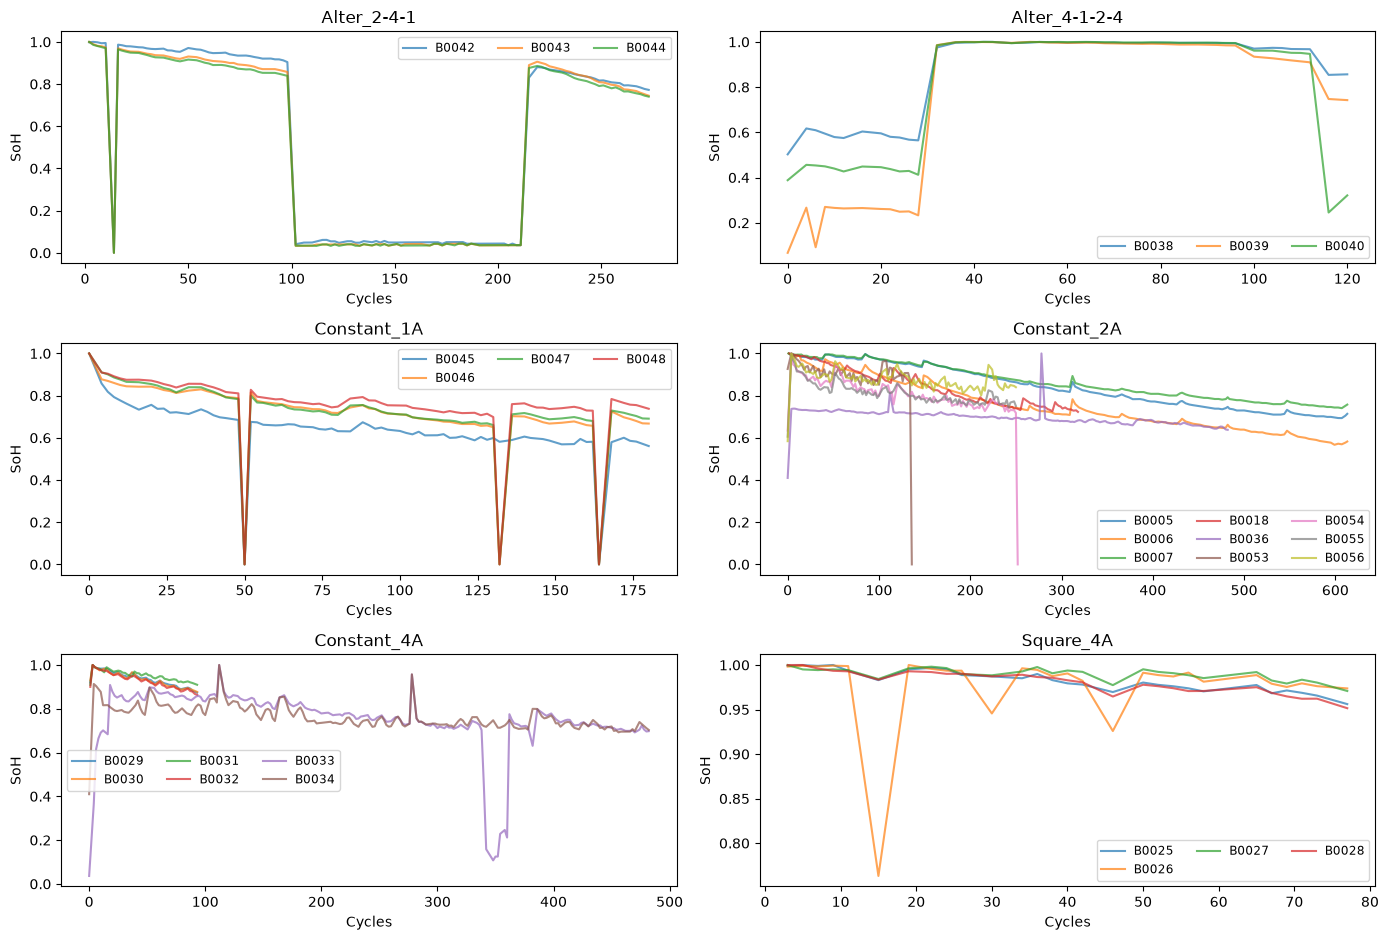

In [16]:
# Plot SoH vs. cycle number for each discharge type to spot abnormal degradation
alt_241 = discharge_df[discharge_df['Discharge_Type'] == 'Alter_2-4-1']
alt_4124 = discharge_df[discharge_df['Discharge_Type'] == 'Alter_4-1-2-4']
const_1A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_1A']
const_2A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_2A']
const_4A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_4A']
square_4A = discharge_df[discharge_df['Discharge_Type'] == 'Square_4A']

discharge_types = {
    "Alter_2-4-1": alt_241,
    "Alter_4-1-2-4": alt_4124,
    "Constant_1A": const_1A,
    "Constant_2A": const_2A,
    "Constant_4A": const_4A,
    "Square_4A": square_4A,
}


fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (label, df) in zip(axes, discharge_types.items()):
    for cell_id, group in df.groupby("Cell_ID"):
        ax.plot(group["Cycle_Number"], group["SoH"], label=cell_id, alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel("Cycles")
    ax.set_ylabel("SoH")
    ax.legend(fontsize="small", loc="best", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Here, we see that some cells encountered some fatal errors that caused the measurement to end or experiencing end-of-life state (SoH < 70%) prematurely. While interesting, the goal of this project is to predict the state of health of normal cells, so we will remove those cells.

# 6. Remove Problem Cells
Based on the plots above, drop cells that failed prematurely or show clearly anomalous degradation, since the goal is modeling *normal* degradation behavior.

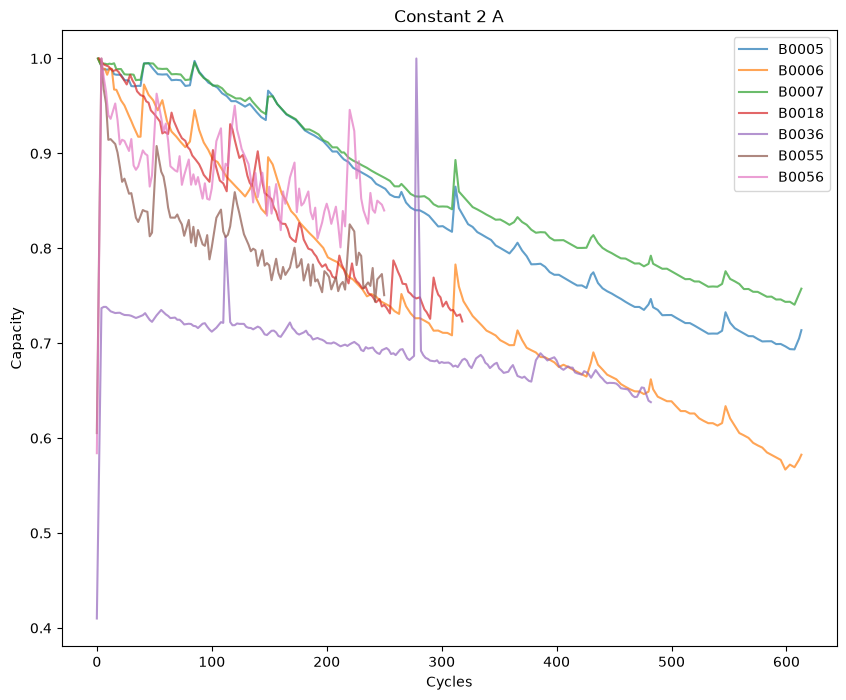

In [18]:
# Re-plot Constant_2A cells after dropping the ones with premature/anomalous end-of-life
const_2A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_2A']
drop2A = ['B0036', 'B0005', 'B0006', 'B0007', 'B0018', 'B0055', 'B0056']
const_2A = const_2A[const_2A['Cell_ID'].isin(drop2A)]
const_2A.groupby('Cell_ID').count()
plt.figure(figsize=(10, 8))
for cell_id, group in const_2A.groupby("Cell_ID"):
        plt.plot(group["Cycle_Number"], group["SoH"], label=cell_id, alpha=0.7)
plt.xlabel('Cycles')
plt.ylabel('Capacity')
plt.title('Constant 2 A')
plt.legend()
plt.show()

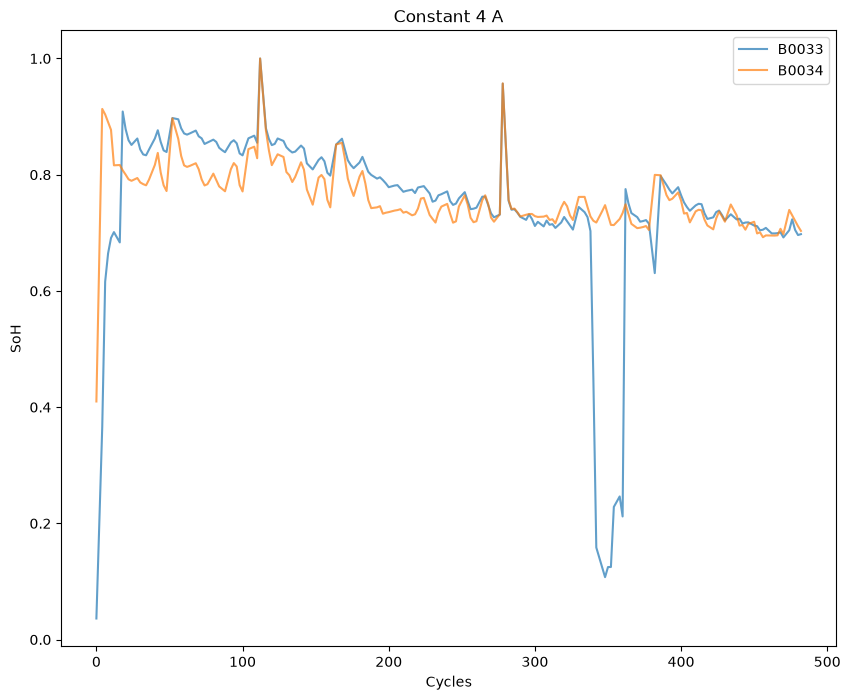

In [19]:
# Re-plot Constant_4A cells after dropping the elevated-temperature (43C) batch
const_4A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_4A']
drop4A = ['B0029', 'B0030', 'B0031', 'B0032']
const_4A = const_4A[~const_4A['Cell_ID'].isin(drop4A)]
const_4A.groupby('Cell_ID').count()
plt.figure(figsize=(10, 8))
for cell_id, group in const_4A.groupby("Cell_ID"):
        plt.plot(group["Cycle_Number"], group["SoH"], label=cell_id, alpha=0.7)
plt.xlabel('Cycles')
plt.ylabel('SoH')
plt.title('Constant 4 A')
plt.legend()
plt.show()

To Drop: Batteries 29-32, 49-54

In [20]:
# Drop cells that fail prematurely or show anomalous degradation from all three dataframes
drop = ['B0029', 'B0030', 'B0031', 'B0032', 'B0049', 'B0050', 'B0051', 'B0052', 'B0053', 'B0054']

charge_df = charge_df[~charge_df['Cell_ID'].isin(drop)]
discharge_df = discharge_df[~discharge_df['Cell_ID'].isin(drop)]
eis_df = eis_df[~eis_df['Cell_ID'].isin(drop)]

In [21]:
# Confirm dtypes and row counts after removing the problem cells
print("Charge Dataframe:")
print(charge_df.info())
print("\nDischarge Dataframe:")
print(discharge_df.info())
print("\nEIS Dataframe:")
print(eis_df.info())

Charge Dataframe:
<class 'pandas.DataFrame'>
Index: 5444268 entries, 0 to 6512875
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   Voltage_measured      float64       
 1   Current_measured      float64       
 2   Temperature_measured  float64       
 3   Current_charge        float64       
 4   Voltage_charge        float64       
 5   Time                  float64       
 6   Cell_ID               str           
 7   Cycle_Number          int64         
 8   Ambient_Temperature   int64         
 9   Time_abs              datetime64[us]
dtypes: datetime64[us](1), float64(6), int64(2), str(1)
memory usage: 456.9 MB
None

Discharge Dataframe:
<class 'pandas.DataFrame'>
Index: 687175 entries, 0 to 746333
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      687175 non-null  float64       
 1 

# 7. Re-check Cleaned Data
Re-plot SoH trends and correlations after dropping the problem cells to confirm the cleaned dataset looks reasonable.

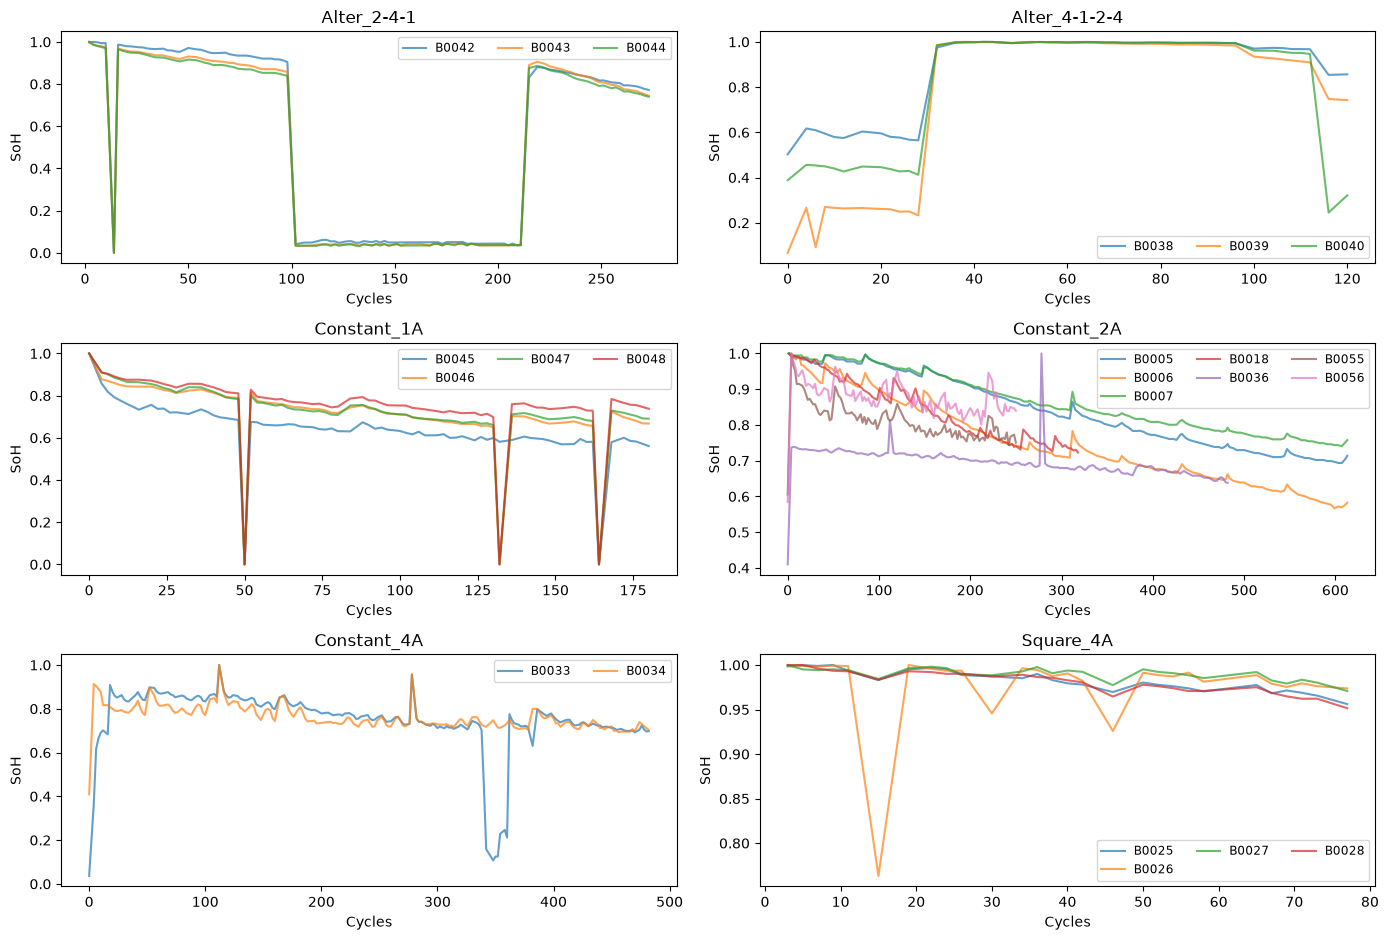

In [22]:
# Re-plot SoH vs. cycle number by discharge type on the cleaned dataset
alt_241 = discharge_df[discharge_df['Discharge_Type'] == 'Alter_2-4-1']
alt_4124 = discharge_df[discharge_df['Discharge_Type'] == 'Alter_4-1-2-4']
const_1A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_1A']
const_2A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_2A']
const_4A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_4A']
square_4A = discharge_df[discharge_df['Discharge_Type'] == 'Square_4A']

discharge_types = {
    "Alter_2-4-1": alt_241,
    "Alter_4-1-2-4": alt_4124,
    "Constant_1A": const_1A,
    "Constant_2A": const_2A,
    "Constant_4A": const_4A,
    "Square_4A": square_4A,
}


fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, (label, df) in zip(axes, discharge_types.items()):
    for cell_id, group in df.groupby("Cell_ID"):
        ax.plot(group["Cycle_Number"], group["SoH"], label=cell_id, alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel("Cycles")
    ax.set_ylabel("SoH")
    ax.legend(fontsize="small", loc="best", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [23]:
#Check the correlation matrix
numeric_cols = discharge_df.select_dtypes(include='number')
disc_corr_mat = numeric_cols.corr()
disc_corr_mat

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,Cycle_Number,Ambient_Temperature,Capacity,discharge_current_A,ambient_C,cutoff_V,endoflife_criteria,SoH
Voltage_measured,1.000000,0.400522,-0.090255,-0.387048,0.191238,-0.349796,-0.041045,0.154336,0.070457,0.001841,0.074249,0.104150,-0.015887,0.025644
Current_measured,0.400522,1.000000,-0.223803,-0.865028,-0.200369,0.439816,-0.129788,-0.126988,-0.118328,-0.062068,-0.209217,-0.045814,0.090056,-0.005080
Temperature_measured,-0.090255,-0.223803,1.000000,0.174075,-0.157159,0.062183,0.142910,0.908720,0.537887,0.660877,0.826298,-0.076941,-0.557537,0.296155
Current_load,-0.387048,-0.865028,0.174075,1.000000,0.143407,-0.381211,0.186527,0.083795,0.012889,0.088423,0.119998,0.025833,-0.131102,-0.070018
Voltage_load,0.191238,-0.200369,-0.157159,0.143407,1.000000,-0.236222,-0.076828,0.028559,0.250252,-0.511091,-0.180690,0.352037,0.238142,0.267276
Time,-0.349796,0.439816,0.062183,-0.381211,-0.236222,1.000000,-0.213378,0.070194,0.181575,0.063825,-0.068737,-0.043145,0.013966,0.267947
Cycle_Number,-0.041045,-0.129788,0.142910,0.186527,-0.076828,-0.213378,1.000000,0.067600,-0.132983,-0.028019,0.339757,0.028143,-0.024998,-0.338317
Ambient_Temperature,0.154336,-0.126988,0.908720,0.083795,0.028559,0.070194,0.067600,1.000000,0.613353,0.604095,0.903489,0.028358,-0.552749,0.376794
Capacity,0.070457,-0.118328,0.537887,0.012889,0.250252,0.181575,-0.132983,0.613353,1.000000,0.369729,0.572112,0.167344,-0.190220,0.827608
discharge_current_A,0.001841,-0.062068,0.660877,0.088423,-0.511091,0.063825,-0.028019,0.604095,0.369729,1.000000,0.604095,-0.384580,-0.502162,0.303490


Next steps would be to model using XGBoost, RandomForest, and LightGBM.

# 8. Additional EDA
Quick sanity checks on `discharge_df`.

In [26]:
# Quick sanity check on the cleaned discharge dataframe
discharge_df.info()

<class 'pandas.DataFrame'>
Index: 687175 entries, 0 to 746333
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Voltage_measured      687175 non-null  float64       
 1   Current_measured      687175 non-null  float64       
 2   Temperature_measured  687175 non-null  float64       
 3   Current_load          687175 non-null  float64       
 4   Voltage_load          687175 non-null  float64       
 5   Time                  687175 non-null  float64       
 6   Cell_ID               687175 non-null  str           
 7   Cycle_Number          687175 non-null  int64         
 8   Ambient_Temperature   687175 non-null  int64         
 9   Time_abs              687175 non-null  datetime64[us]
 10  Capacity              687175 non-null  float64       
 11  discharge_mode        687175 non-null  str           
 12  discharge_current_A   535668 non-null  float64       
 13  ambient_C      

In [27]:
#grouping the discharge dataframe based on cycling patterns and creating a dictionary of the discharge types
alt_241 = discharge_df[discharge_df['Discharge_Type'] == 'Alter_2-4-1']
alt_4124 = discharge_df[discharge_df['Discharge_Type'] == 'Alter_4-1-2-4']
const_1A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_1A']
const_2A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_2A']
const_4A = discharge_df[discharge_df['Discharge_Type'] == 'Constant_4A']
square_4A = discharge_df[discharge_df['Discharge_Type'] == 'Square_4A']
discharge_types = {
    "Alter_2-4-1": alt_241,
    "Alter_4-1-2-4": alt_4124,
    "Constant_1A": const_1A,
    "Constant_2A": const_2A,
    "Constant_4A": const_4A,
    "Square_4A": square_4A,
}

# 9. Aggregate to Per-Cycle Summary Tables
Collapse the raw time-series rows into one row per (Cell_ID, Cycle_Number): `discharge_sum_df` summarizes each discharge cycle, `eis_sum_df` summarizes each impedance measurement cycle.

In [28]:
# Collapse discharge_df to one row per (Cell_ID, Cycle_Number) with per-cycle summary stats
discharge_sum_df = (
    discharge_df
    .groupby(["Cell_ID", "Cycle_Number"])
    .agg({
        "Time": lambda x: x.max() - x.min(),
        "Discharge_Type": "first",
        "discharge_current_A": "first",
        "Voltage_measured": lambda x: x.iloc[0] - x.iloc[-1],
        "Current_measured": "min",
        "Temperature_measured": lambda x: x.max() - x.iloc[0],
        "Ambient_Temperature": "mean",
        "Voltage_load": "mean",
        "Current_load": "mean",
        "cutoff_V": "mean",
        "Capacity": "mean",
        "SoH": "mean",
    })
    .reset_index()
)
discharge_sum_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2375 entries, 0 to 2374
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cell_ID               2375 non-null   str    
 1   Cycle_Number          2375 non-null   int64  
 2   Time                  2375 non-null   float64
 3   Discharge_Type        2375 non-null   str    
 4   discharge_current_A   1831 non-null   float64
 5   Voltage_measured      2375 non-null   float64
 6   Current_measured      2375 non-null   float64
 7   Temperature_measured  2375 non-null   float64
 8   Ambient_Temperature   2375 non-null   float64
 9   Voltage_load          2375 non-null   float64
 10  Current_load          2375 non-null   float64
 11  cutoff_V              2375 non-null   float64
 12  Capacity              2375 non-null   float64
 13  SoH                   2375 non-null   float64
dtypes: float64(11), int64(1), str(2)
memory usage: 259.9 KB


In [30]:
# Collapse eis_df to one row per (Cell_ID, Cycle_Number), tagged as 'EIS' for merging
eis_sum_df = (
    eis_df
    .groupby(["Cell_ID", "Cycle_Number"])
    .agg({
        "Ambient_Temperature":"mean",
        "R_Electrolyte": "mean",
        "R_Charge_Transfer": "mean"
    })
    .reset_index()
)
eis_sum_df["Discharge_Type"] = "EIS" #to ease merging with the discharge database

eis_sum_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1766 entries, 0 to 1765
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cell_ID              1766 non-null   str    
 1   Cycle_Number         1766 non-null   int64  
 2   Ambient_Temperature  1766 non-null   float64
 3   R_Electrolyte        1766 non-null   float64
 4   R_Charge_Transfer    1766 non-null   float64
 5   Discharge_Type       1766 non-null   str    
dtypes: float64(3), int64(1), str(2)
memory usage: 82.9 KB


# 10. Merge EIS Features into Charge-Discharge Summary
EIS cycles don't align 1:1 with discharge cycles, so shift EIS cycle numbers +/-1 to match the discharge cycle immediately before/after each impedance scan, merge both into `discharge_eis_df`, and drop rows with missing EIS data to get `discharge_eis_clean`.

In [33]:
eis_dis = eis_sum_df.copy()
eis_dis['Cycle_Number'] = eis_dis['Cycle_Number'] - 1

eis_charge = eis_sum_df.copy()
eis_charge['Cycle_Number'] = eis_charge['Cycle_Number'] + 1

# Merge discharge info
discharge_eis_df = discharge_sum_df.merge(
    eis_dis[['Cell_ID', 'Cycle_Number', 'R_Electrolyte', 'R_Charge_Transfer']],
    on=['Cell_ID', 'Cycle_Number'],
    how='left'
)
discharge_eis_df.rename(columns={
    'R_Electrolyte': 're_dis',
    'R_Charge_Transfer': 'rct_dis'
}, inplace=True)

# Merge charge info
discharge_eis_df = discharge_eis_df.merge(
    eis_charge[['Cell_ID', 'Cycle_Number', 'R_Electrolyte', 'R_Charge_Transfer']],
    on=['Cell_ID', 'Cycle_Number'],
    how='left'
)
discharge_eis_df.rename(columns={
    'R_Electrolyte': 're_charge',
    'R_Charge_Transfer': 'rct_charge'
}, inplace=True)

discharge_eis_df.head()

,Cell_ID,Cycle_Number,Time,Discharge_Type,discharge_current_A,Voltage_measured,Current_measured,Temperature_measured,Ambient_Temperature,Voltage_load,Current_load,cutoff_V,Capacity,SoH,re_dis,rct_dis,re_charge,rct_charge
0,B0005,1,3690.234,Constant_2A,2.0,0.914322,-2.018015,14.652147,24.0,2.404944,-1.805570,2.7,1.856487,1.000000,NaN,NaN,NaN,NaN
1,B0005,3,3672.344,Constant_2A,2.0,0.889528,-2.016821,14.335646,24.0,2.399260,-1.804583,2.7,1.846327,0.994527,NaN,NaN,NaN,NaN
2,B0005,5,3651.641,Constant_2A,2.0,0.860736,-2.016574,14.084531,24.0,2.397969,-1.803575,2.7,1.835349,0.988614,NaN,NaN,NaN,NaN
3,B0005,7,3631.563,Constant_2A,2.0,0.874279,-2.015936,14.108068,24.0,2.408289,-1.812863,2.7,1.835263,0.988567,NaN,NaN,NaN,NaN
4,B0005,9,3629.172,Constant_2A,2.0,0.882802,-2.017426,14.140596,24.0,2.408505,-1.812876,2.7,1.834646,0.988235,NaN,NaN,NaN,NaN


[re_dis], [rct_dis], [re_charge], and [rct_charge] shows NaN because the impedance measurements happen at different cycles than discharge cycles, not to mention for B0005 the first impedance measurement happened at Cycle 40.

In [34]:
# Create columns in discharge_sum_df
dis_sum_df = discharge_sum_df.copy()

In [35]:
# Check null/non-null counts per column after merging EIS into the discharge summary
info_df = pd.DataFrame({
    'dtype': discharge_eis_df.dtypes,
    'num_nulls': discharge_eis_df.isnull().sum(),
    'num_non_null': discharge_eis_df.notnull().sum()
})
info_df


,dtype,num_nulls,num_non_null
Cell_ID,str,0,2375
Cycle_Number,int64,0,2375
Time,float64,0,2375
Discharge_Type,str,0,2375
discharge_current_A,float64,544,1831
Voltage_measured,float64,0,2375
Current_measured,float64,0,2375
Temperature_measured,float64,0,2375
Ambient_Temperature,float64,0,2375
Voltage_load,float64,0,2375


In [36]:
# Drop rows with missing EIS data and move Capacity/SoH to the end of the column order
discharge_eis_clean = discharge_eis_df.dropna()
discharge_eis_clean = discharge_eis_clean[[c for c in discharge_eis_df.columns if c not in ['Capacity','SoH']] + ['Capacity','SoH']]

discharge_eis_clean.info()

<class 'pandas.DataFrame'>
Index: 479 entries, 19 to 2362
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cell_ID               479 non-null    str    
 1   Cycle_Number          479 non-null    int64  
 2   Time                  479 non-null    float64
 3   Discharge_Type        479 non-null    str    
 4   discharge_current_A   479 non-null    float64
 5   Voltage_measured      479 non-null    float64
 6   Current_measured      479 non-null    float64
 7   Temperature_measured  479 non-null    float64
 8   Ambient_Temperature   479 non-null    float64
 9   Voltage_load          479 non-null    float64
 10  Current_load          479 non-null    float64
 11  cutoff_V              479 non-null    float64
 12  re_dis                479 non-null    float64
 13  rct_dis               479 non-null    float64
 14  re_charge             479 non-null    float64
 15  rct_charge            479 non-null   

# 11. Correlation Analysis.

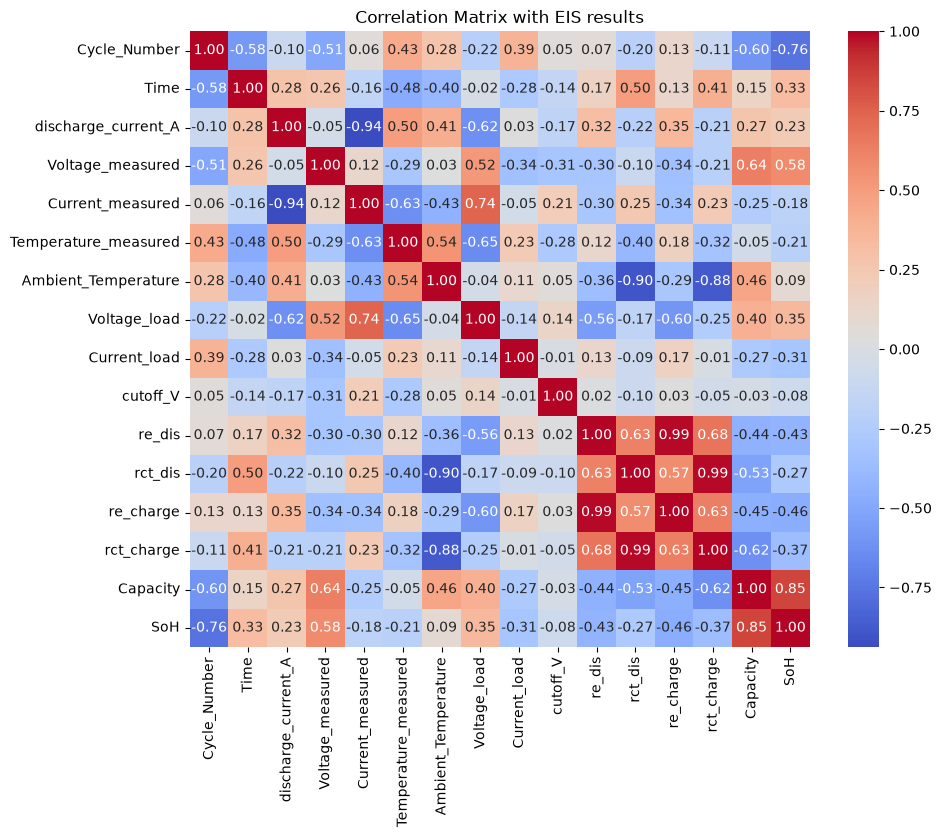

In [37]:
# Correlation heatmap of all numeric columns, including the EIS-derived resistances
numeric_df = discharge_eis_clean.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
seaborn.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix with EIS results")
plt.show()

We observe that (ignoring the Capacity as SoH is directly determined by it) there is a great positive correlation between Time_rel_s, measured and load voltages and currents with the SoH. The EIS parameters, R_Electrolyte and R_Charge_Transfer have negative correlation with the SoH. 

# 12. Preprocess for Modeling
One-hot encode `Discharge_Type`, split into train/test **by Cell_ID** (critical — this prevents cycles from the same battery leaking across train and test), then one-hot encode `Cell_ID` and align train/test columns.

Turning Discharge Types into dummy variables.

In [38]:
# One-hot encode Discharge_Type and drop the raw Capacity column (SoH is the modeling target)
discharge_eis_clean = pd.get_dummies(discharge_eis_clean, columns=['Discharge_Type'], drop_first=True)
discharge_eis_clean.drop(columns=['Capacity'], inplace=True)
discharge_eis_clean.head()

,Cell_ID,Cycle_Number,Time,discharge_current_A,Voltage_measured,Current_measured,Temperature_measured,Ambient_Temperature,Voltage_load,Current_load,cutoff_V,re_dis,rct_dis,re_charge,rct_charge,SoH,Discharge_Type_Constant_2A,Discharge_Type_Constant_4A,Discharge_Type_Square_4A
19,B0005,41,3591.734,2.0,0.928874,-2.016847,13.888784,24.0,2.448323,-1.842201,2.7,0.046687,0.076275,0.044669,0.069456,0.994904,True,False,False
20,B0005,45,3552.297,2.0,0.969583,-2.016191,14.070169,24.0,2.474068,-1.861526,2.7,0.046195,0.074534,0.044843,0.067972,0.995114,True,False,False
21,B0005,49,3531.578,2.0,0.930138,-2.016760,13.948276,24.0,2.480037,-1.860800,2.7,0.045991,0.073427,0.045101,0.068528,0.989060,True,False,False
22,B0005,53,3492.907,2.0,0.907087,-2.016023,13.949235,24.0,2.492449,-1.870012,2.7,0.045217,0.074648,0.044172,0.068044,0.983460,True,False,False
23,B0005,57,3511.594,2.0,0.907673,-2.017191,14.110271,24.0,2.479261,-1.860064,2.7,0.044910,0.073957,0.043787,0.068450,0.983100,True,False,False


In [39]:
#Separating by cell ID to prevent data leakage
cell_ids = discharge_eis_clean['Cell_ID'].unique()
train_ids, test_ids = train_test_split(cell_ids, test_size=0.3, random_state=42)

train_df = discharge_eis_clean[discharge_eis_clean['Cell_ID'].isin(train_ids)].copy()
test_df  = discharge_eis_clean[discharge_eis_clean['Cell_ID'].isin(test_ids)].copy()

# capture the raw Cell_ID for group-aware CV before it gets one-hot encoded away
train_groups = train_df['Cell_ID'].values

categorical_cols = ['Cell_ID']
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df  = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)
test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

X_train = train_df.drop(columns=['SoH'])
y_train = train_df['SoH']
X_test = test_df.drop(columns=['SoH'])
y_test = test_df['SoH']

print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

Training features shape: (199, 27)
Test features shape: (280, 27)


# 13. Define Model Pipelines, CV Strategy & Hyperparameter Grids
Build scikit-learn `Pipeline`s for Random Forest, XGBoost, and LightGBM, set up 5-fold CV, and define the `GridSearchCV` parameter grids for each model.

In [40]:
# Build a scikit-learn Pipeline for the requested model ('rf', 'xgb', or 'lgb')
def get_pipeline(model_name):
    """
    model_name: 'rf', 'xgb', 'lgb'
    """
    if model_name == 'rf':
        return Pipeline([
            ('scaler', StandardScaler()),  # optional for tree-based models
            ('model', RandomForestRegressor(n_estimators=100, random_state=42))
        ])

    elif model_name == 'xgb':
        return Pipeline([
            ('scaler', StandardScaler()),  # optional
            ('model', XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
        ])

    elif model_name == 'lgb':
        return Pipeline([
                        ('model', LGBMRegressor(n_estimators=100, max_depth=-1, learning_rate=0.1, random_state=42))
        ])

    else:
        raise ValueError("model_name must be one of: 'rf', 'xgb', 'lgb'")

rf_pipeline = get_pipeline('rf')
xgb_pipeline = get_pipeline('xgb')
lgb_pipeline = get_pipeline('lgb')

In [41]:
# 5-fold group-aware CV so rows from the same cell never span train/validation folds
from sklearn.model_selection import GroupKFold
cv = GroupKFold(n_splits=5)

In [42]:
# Hyperparameter grids for the Random Forest, XGBoost, and LightGBM grid searches
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

xg_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 1.0]
}

lgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50],
    'model__min_child_samples': [5, 10]
}

# 14. Train & Evaluate Models
## 14.1 Random Forest

Random Forest Regressor

In [43]:
# Grid-search the Random Forest pipeline with group-aware CV and report the best params/score
rf_model = GridSearchCV(estimator=rf_pipeline, param_grid=rf_param_grid, cv=cv, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
rf_model.fit(X_train, y_train, groups=train_groups)
print("Best parameters:", rf_model.best_params_)
print("Best score (MSE):", -rf_model.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best score (MSE): 0.008745521834283699


In [44]:
# Print and return R2/MSE/RMSE/MAE for a set of predictions
def regression_report(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    return r2, mse, rmse, mae

In [45]:
# Evaluate the tuned Random Forest on the held-out test cells
y_pred_rf = rf_model.predict(X_test)
regression_report(y_test, y_pred_rf)

R²: 0.6615
MSE: 0.0043
RMSE: 0.0655
MAE: 0.0504


(0.6614836320327852,
 0.004292429701107211,
 0.06551663682689467,
 0.050378266078763737)

## 14.2 XGBoost

XGBoost

In [46]:
# Grid-search the XGBoost pipeline with group-aware CV and report the best params/score
xg_model = GridSearchCV(estimator=xgb_pipeline, param_grid=xg_param_grid, cv=cv, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
xg_model.fit(X_train, y_train, groups=train_groups)
print("Best parameters:", xg_model.best_params_)
print("Best score (MSE):", -xg_model.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'model__learning_rate': 0.01, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.7}
Best score (MSE): 0.007125707737670034


In [47]:
# Evaluate the tuned XGBoost model on the held-out test cells
y_pred_xg = xg_model.predict(X_test)
regression_report(y_test, y_pred_xg)

R²: 0.6429
MSE: 0.0045
RMSE: 0.0673
MAE: 0.0515


(0.6428921795596803,
 0.004528171633650949,
 0.06729169067315034,
 0.051468342463230725)

## 14.3 LightGBM

LightGBM

In [48]:
# Grid-search the LightGBM pipeline with group-aware CV and report the best params/score
lg_model = GridSearchCV(estimator=lgb_pipeline, param_grid=lgb_param_grid, cv=cv, scoring='neg_mean_squared_error', verbose=2, n_jobs=-1)
lg_model.fit(X_train, y_train, groups=train_groups)
print("Best parameters:", lg_model.best_params_)
print("Best score (MSE):", -lg_model.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 756
[LightGBM] [Info] Number of data points in the train set: 199, number of used features: 18
[LightGBM] [Info] Start training from score 0.849795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

In [49]:
# Evaluate the tuned LightGBM model on the held-out test cells
y_pred_lg = lg_model.predict(X_test)
regression_report(y_test, y_pred_lg)

R²: 0.7835
MSE: 0.0027
RMSE: 0.0524
MAE: 0.0387


(0.7835342567615596,
 0.0027448125806398757,
 0.05239095895896424,
 0.03870142611449571)

## 14.4 Compare Model Results
Collect R2/MSE/RMSE/MAE across all three models and plot them side by side.

R²: 0.6615
MSE: 0.0043
RMSE: 0.0655
MAE: 0.0504
R²: 0.6429
MSE: 0.0045
RMSE: 0.0673
MAE: 0.0515
R²: 0.7835
MSE: 0.0027
RMSE: 0.0524
MAE: 0.0387


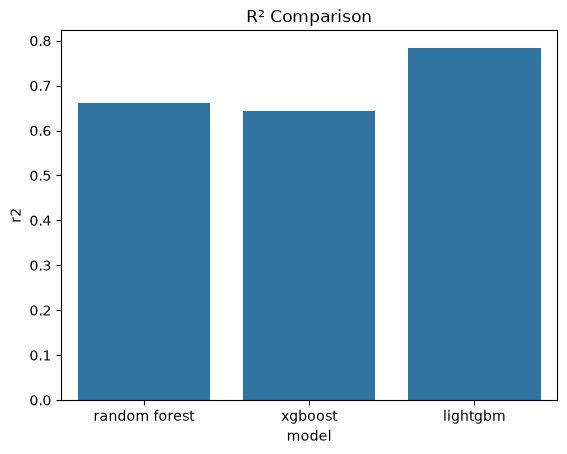

In [50]:
# Collect R2/MSE/RMSE/MAE for all three models and compare R2 side by side
r2 = []
mse = []
rmse = []
mae = []
r2_rf, mse_rf, rmse_rf, mae_rf = regression_report(y_test, y_pred_rf)
r2.append(r2_rf)
mse.append(mse_rf)
rmse.append(rmse_rf)
mae.append(mae_rf)
r2_xg, mse_xg, rmse_xg, mae_xg = regression_report(y_test, y_pred_xg)
r2.append(r2_xg)
mse.append(mse_xg)
rmse.append(rmse_xg)
mae.append(mae_xg)
r2_lg, mse_lg, rmse_lg, mae_lg = regression_report(y_test, y_pred_lg)
r2.append(r2_lg)
mse.append(mse_lg)
rmse.append(rmse_lg)
mae.append(mae_lg)

results_df = pd.DataFrame({
    "model": ["random forest", "xgboost", "lightgbm"],
    "r2": r2,
    "mse": mse,
    "rmse": rmse,
    "mae": mae
})


sns.barplot(data=results_df, x="model", y="r2")
plt.title("R² Comparison")
plt.show()


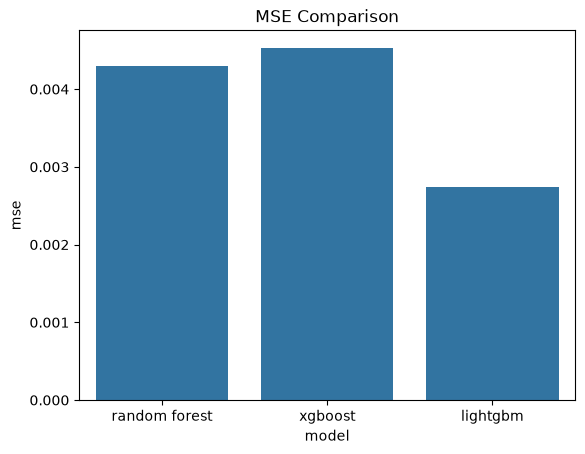

In [51]:
# Compare MSE side by side across all three models
sns.barplot(data=results_df, x="model", y="mse")
plt.title("MSE Comparison")
plt.show()

## 15. Feature Importance of the Three Models

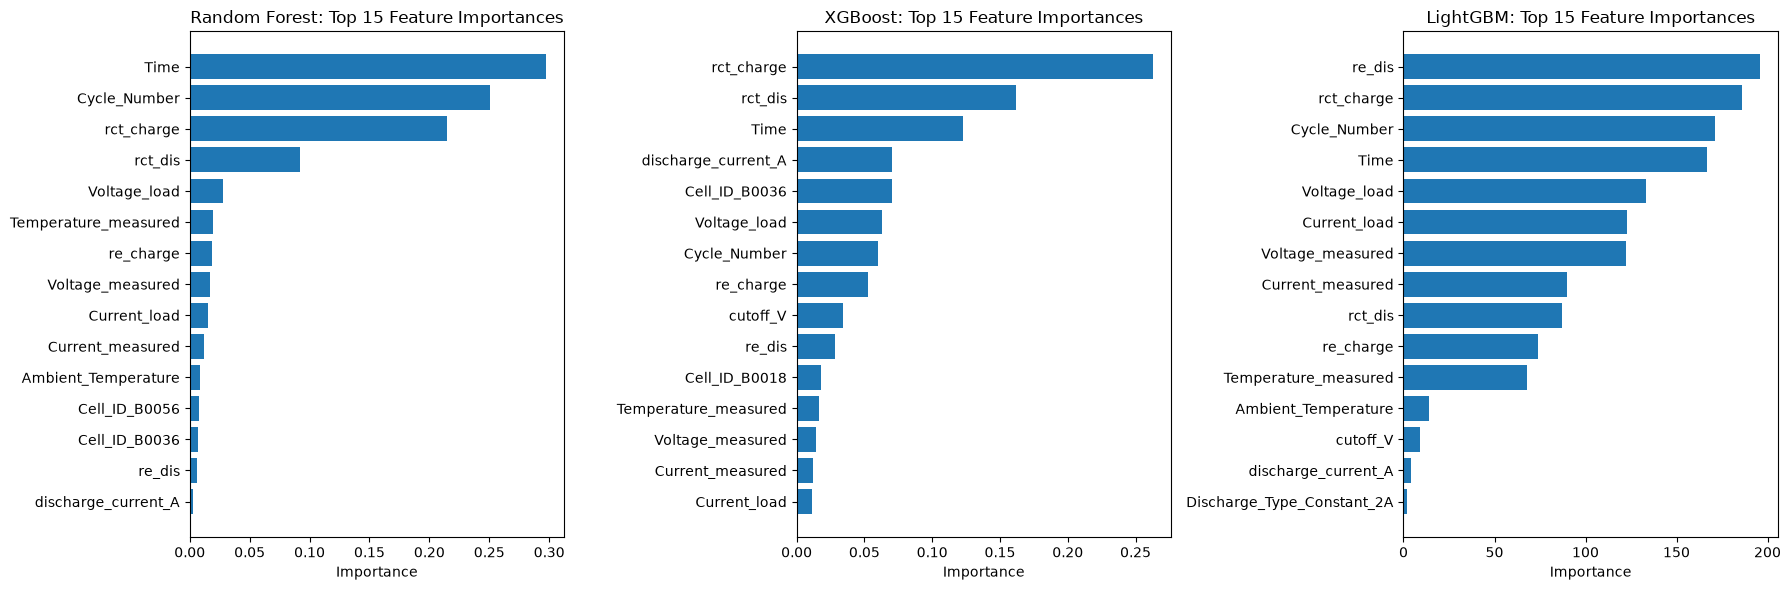

In [52]:
# Pull the fitted estimator out of each GridSearchCV/Pipeline and grab its feature importances.
def get_importances(fitted_grid_search, feature_names):
    model = fitted_grid_search.best_estimator_.named_steps['model']
    imp = pd.Series(model.feature_importances_, index=feature_names)
    return imp.sort_values(ascending=False)

feature_names = X_train.columns

imp_rf = get_importances(rf_model, feature_names)
imp_xg = get_importances(xg_model, feature_names)
imp_lg = get_importances(lg_model, feature_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp, name in zip(axes, [imp_rf, imp_xg, imp_lg], ["Random Forest", "XGBoost", "LightGBM"]):
    top_n = imp.head(15)  # keep it readable — full feature set includes one-hot Cell_ID columns
    ax.barh(top_n.index[::-1], top_n.values[::-1])
    ax.set_title(f"{name}: Top 15 Feature Importances")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

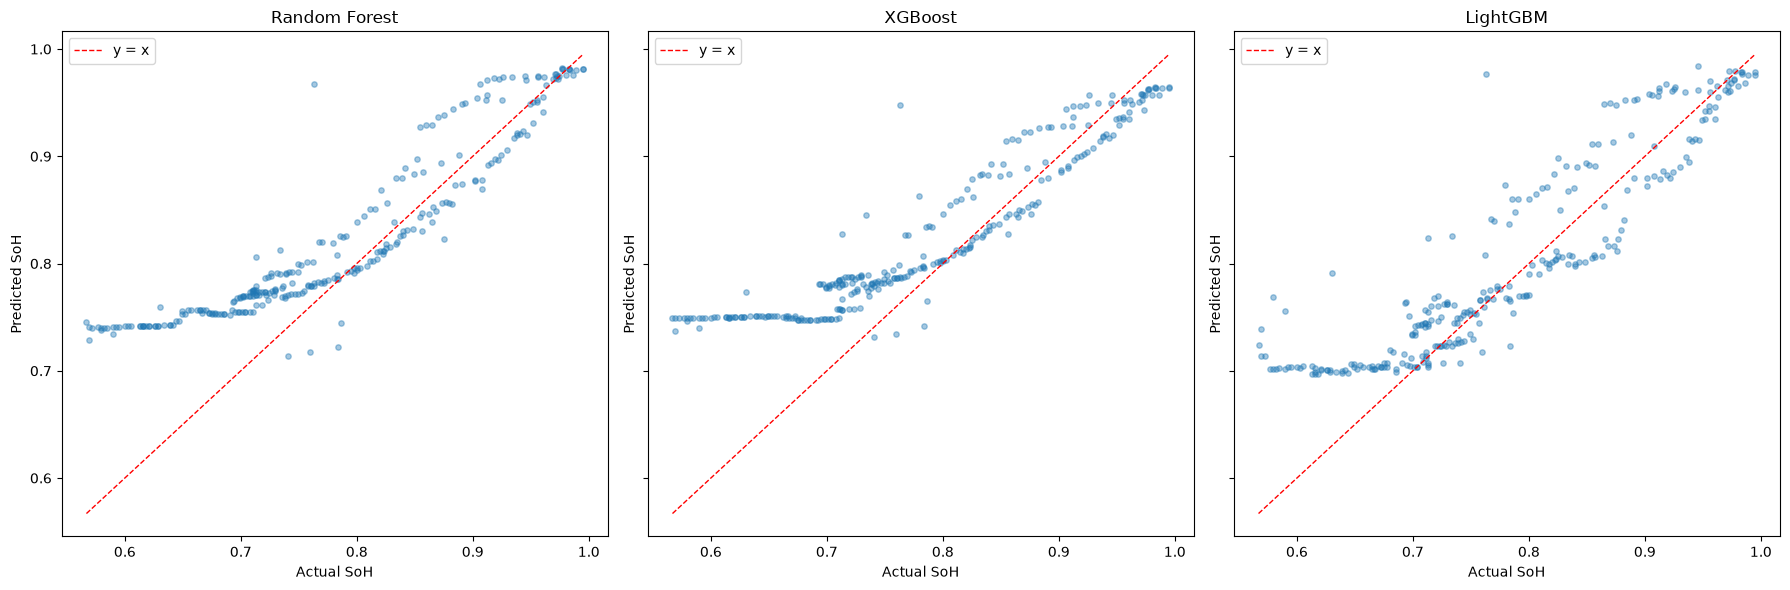

In [53]:
# Bar charts of aggregate R²/MSE hide systematic bias — e.g. a model that's
# accurate mid-range but drifts near end-of-life (SoH < 0.7), which is the
# region that matters most for a real SoH predictor. This shows that directly.
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
preds = [y_pred_rf, y_pred_xg, y_pred_lg]
names = ["Random Forest", "XGBoost", "LightGBM"]

for ax, y_pred, name in zip(axes, preds, names):
    ax.scatter(y_test, y_pred, alpha=0.4, s=15)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='y = x')
    ax.set_xlabel("Actual SoH")
    ax.set_ylabel("Predicted SoH")
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

# 16. Conclusion

**LightGBM was the best-performing model**, beating both Random Forest and XGBoost on every metric (R² = 0.78 vs. 0.66 and 0.64; also lowest MSE, RMSE, and MAE) after hyperparameter tuning.

For LightGBM, the **electrolytic resistance after a discharge cycle (re_dis)** is the most important feature. 
For XGBoost, the **charge transfer resistance after a charging cycle (rct_charge)** is the most important feature.
For Random Forest, **the experiment duration and cycle number** are the most important features.

For future works, the author will attempt to re-fit available impedance data using a proper ECM to see if other parameters could affect the SoH even more. However, since the dataset does not include any explanation regarding the ECM used to fit the EIS data or even if any datapoints were omitted due to high Kramers-Kronig relation residuals, this is still a work in progress. 